# Object Tracking

- What is tracking?
- Tracking in computer vison.
- Motion model and appearance model.
- OpenCV API Tracker Class.

| Model     | Time | Tracking Quality |
|-----------|------|------------------|
| Nano      | 9s   | *****            |
| VIT       | 8.6s | ****             |
| DaSiamRPN | 54s  | *****            |
| GOTURN    | 31s  | ****             |
| MIL       | 53s  | ***              |

In [1]:
import os
import sys
import cv2
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import YouTubeVideo, display, HTML
from base64 import b64encode
from matplotlib.ticker import MultipleLocator

%matplotlib inline

In [2]:
def download_and_unzip(url, save_path):
    print("Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/ld535c8e0vueq6x/opencv_bootcamp_assets_NB11.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB11.zip")

# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

# Tracker Class in OpenCV

1. BOOSTING
2. MIL
3. KCF
4. CRST
5. TLD - Tends to recover from occulusions
6. MEDIANFLOW - Good for predictable slow motion
7. GOTURN - Deep Learning based, Most Accurate
8. MOSSE - Fastest

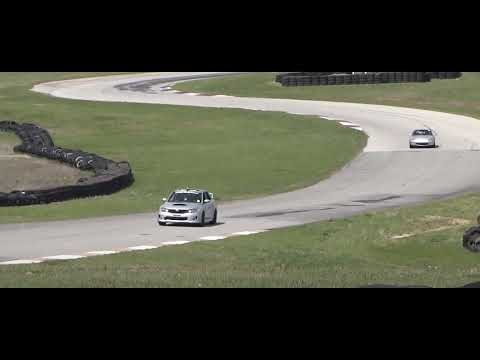

In [4]:
video = YouTubeVideo("XkJCvtCRdVM", width=1024, height=640)
display(video)

In [8]:
video_input_file_name = "race_car.mp4"


def drawRectangle(frame, bbox):
    p1 = (int(bbox[0]), int(bbox[1]))
    p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv2.rectangle(frame, p1, p2, (255, 0, 0), 2, 1)


def displayRectangle(frame, bbox):
    plt.figure(figsize=(20, 10))
    frameCopy = frame.copy()
    drawRectangle(frameCopy, bbox)
    frameCopy = cv2.cvtColor(frameCopy, cv2.COLOR_RGB2BGR)
    plt.imshow(frameCopy)
    plt.axis("off")


def drawText(frame, txt, location, color=(50, 170, 50)):
    cv2.putText(frame, txt, location, cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)

# Create the Tracker instance

In [5]:
# Set up tracker
tracker_types = [
    "MIL",
    "Nano",
    "VIT",
    "DaSiamRPN",
    "GOTURN",
]

# Change the index to change the tracker type
tracker_type = tracker_types[0]

if tracker_type == "MIL":
    tracker = cv2.TrackerMIL.create()
elif tracker_type == "Nano":
    # https://github.com/HonglinChu/SiamTrackers/tree/master/NanoTrack/models/nanotrackv2

    backbone = 'models/nano_track/nanotrack_backbone_sim.onnx'
    neckhead = 'models/nano_track/nanotrack_head_sim.onnx'

    params = cv2.TrackerNano_Params()
    params.backbone = str(backbone)
    params.neckhead = str(neckhead)
    params.backend = cv2.dnn.DNN_BACKEND_OPENCV
    params.target = cv2.dnn.DNN_TARGET_CPU

    tracker = cv2.TrackerNano.create(params)
elif tracker_type == "VIT":
    # https://github.com/opencv/opencv_zoo/tree/main/models/object_tracking_vittrack

    params = cv2.TrackerVit_Params()
    params.net = 'models/vittrack/object_tracking_vittrack_2023sep.onnx'
    params.backend = cv2.dnn.DNN_BACKEND_OPENCV
    params.target = cv2.dnn.DNN_TARGET_CPU

    tracker = cv2.TrackerVit.create(params)
elif tracker_type == "DaSiamRPN":
    # https://github.com/opencv/opencv/blob/4.x/samples/python/tracker.py
    # https://www.dropbox.com/s/rr1lk9355vzolqv/dasiamrpn_model.onnx?dl=0
    # https://www.dropbox.com/s/999cqx5zrfi7w4p/dasiamrpn_kernel_r1.onnx?dl=0
    params = cv2.TrackerDaSiamRPN_Params()
    params.model = 'models/dasiamrpn/dasiamrpn_model.onnx'
    params.kernel_cls1 = 'models/dasiamrpn/dasiamrpn_kernel_cls1.onnx'
    params.kernel_r1 = 'models/dasiamrpn/dasiamrpn_kernel_r1.onnx'
    params.backend = cv2.dnn.DNN_BACKEND_OPENCV
    params.target = cv2.dnn.DNN_TARGET_CPU

    tracker = cv2.TrackerDaSiamRPN.create(params)
elif tracker_type == "GOTURN":
    tracker = cv2.TrackerGOTURN.create()

# Read input video & Setup output Video

In [9]:
# Read video
video = cv2.VideoCapture(video_input_file_name)
ok, frame = video.read()

# Exit if video not opened
if not video.isOpened():
    print("Could not open video")
    sys.exit()
else:
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

video_output_file_name = "race_car-" + tracker_type + ".mp4"
video_out = cv2.VideoWriter(video_output_file_name, cv2.VideoWriter_fourcc(*"XVID"), 10, (width, height))

video_output_file_name

'race_car-MIL.mp4'

# Define Bounding Box

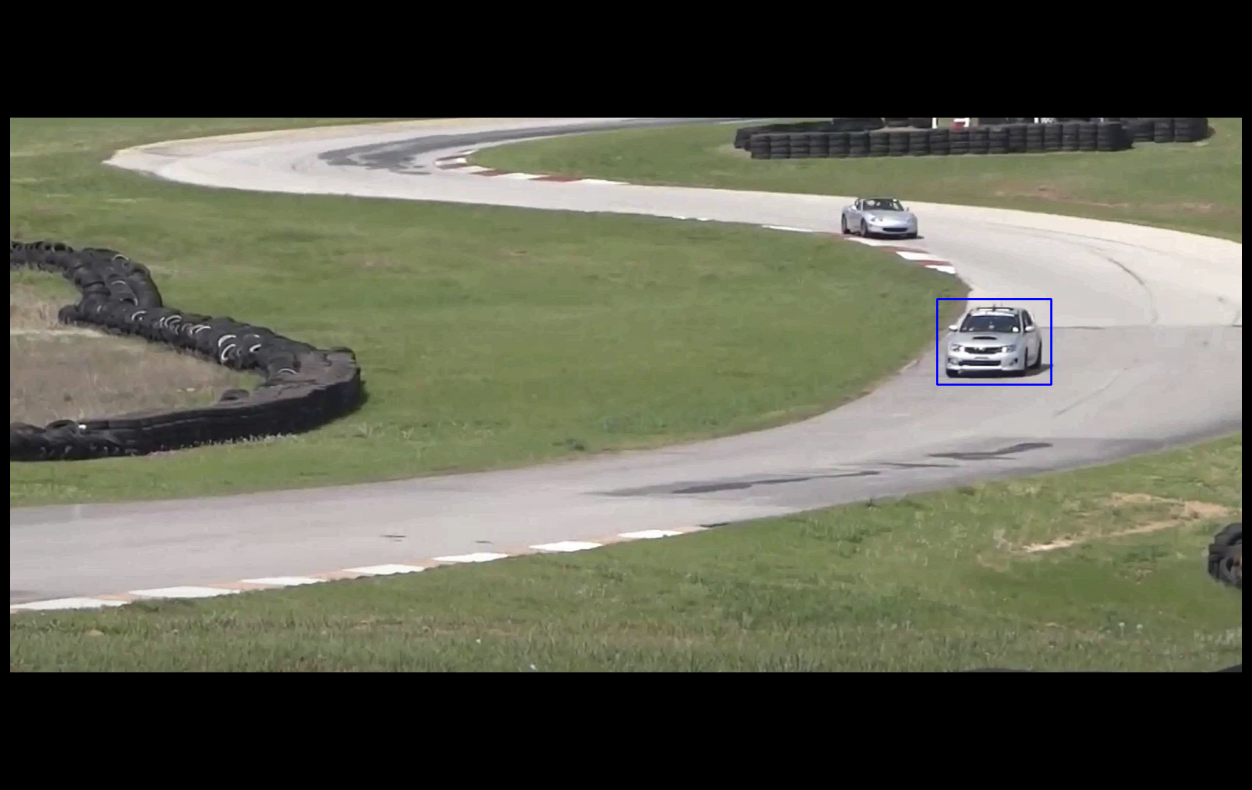

In [10]:
# Define a bounding box
bbox = (1300, 405, 160, 120)
# bbox = cv2.selectROI(frame, False)
# print(bbox)
displayRectangle(frame, bbox)

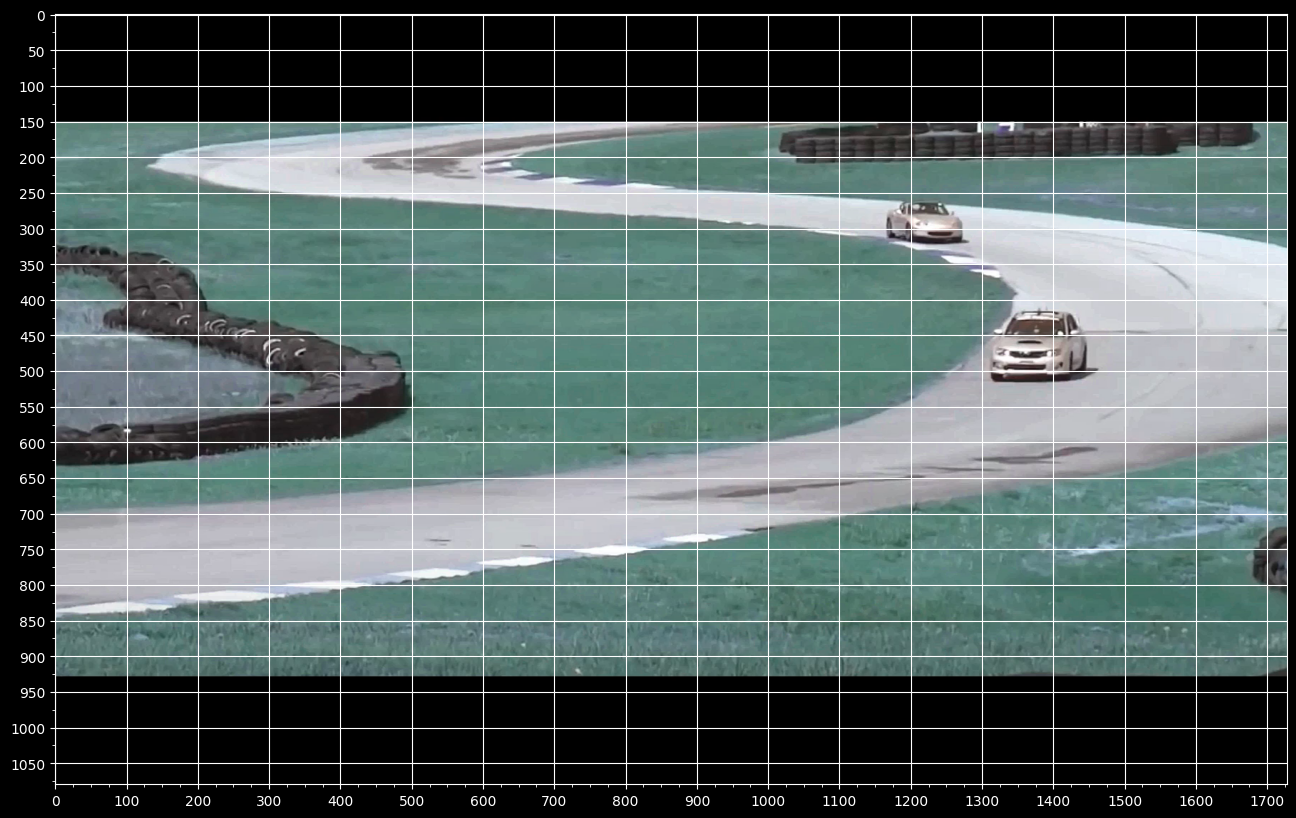

In [12]:
plt.figure(figsize=(20, 10))
plt.imshow(frame)
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.yaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.yaxis.set_minor_locator(MultipleLocator(25))

# Intilialize Tracker

In [37]:
# Initialize tracker with first frame and bounding box

ok = tracker.init(frame, bbox)

# Read frame and Track Object

In [38]:
while True:
    ok, frame = video.read()

    if not ok:
        break

    # Start timer
    timer = cv2.getTickCount()

    # Update tracker
    ok, bbox = tracker.update(frame)

    # Calculate Frames per second (FPS)
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - timer)

    # Draw bounding box
    if ok:
        drawRectangle(frame, bbox)
    else:
        drawText(frame, "Tracking failure detected", (80, 140), (0, 0, 255))

    # Display Info
    drawText(frame, tracker_type + " Tracker", (80, 60))
    drawText(frame, "FPS : " + str(int(fps)), (80, 100))

    # Write frame to video
    video_out.write(frame)

video.release()
video_out.release()

# Render MP4 Video

In [ ]:
mp4 = open("images/race_car-MIL.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""<video width=1024 controls><source src="{data_url}" type="video/mp4"></video>""")